In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


In [12]:
def read_table(path):
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    return pd.read_csv(path, sep=None, engine="python")


path = Path("data/MGNT.csv")
data = read_table(path)
data.head()


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,MGNT,D,20140113,0,8497.7,8550.0,8050.0,8258.5,438238
1,MGNT,D,20140114,0,8200.0,8500.0,8073.0,8414.0,283378
2,MGNT,D,20140115,0,8465.0,9020.0,8432.1,8902.9,496478
3,MGNT,D,20140116,0,8893.0,9139.7,8883.0,9025.5,336623
4,MGNT,D,20140117,0,9000.0,9093.8,8825.0,8975.5,236919


In [13]:
def normalize_columns(data):
    df = data.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df


def find_column(df, variants):
    for col in df.columns:
        low = col.lower().replace(" ", "")
        if any(name in low for name in variants):
            return col
    return None


def parse_date_column(values):
    text = values.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

    parsed = pd.to_datetime(text, format="%Y%m%d", errors="coerce")
    if parsed.notna().mean() > 0.7:
        return parsed

    return pd.to_datetime(values, errors="coerce")


prices = normalize_columns(data)

date_col = find_column(prices, ["date", "дата", "time"])
close_col = find_column(prices, ["close", "закр", "last"])
open_col = find_column(prices, ["open", "откр"])
high_col = find_column(prices, ["high", "max", "макс"])
low_col = find_column(prices, ["low", "min", "мин"])
volume_col = find_column(prices, ["volume", "vol", "объем", "объём"])

if close_col is None:
    numeric = prices.apply(pd.to_numeric, errors="coerce")
    numeric_cols = [col for col in numeric.columns if numeric[col].notna().sum() > 10]
    close_col = numeric[numeric_cols].var(numeric_only=True).idxmax()

if date_col is not None:
    prices[date_col] = parse_date_column(prices[date_col])
    prices = prices.sort_values(date_col)
    prices = prices.set_index(date_col)

close = pd.to_numeric(prices[close_col], errors="coerce").dropna().astype(float)
close = close[~close.index.duplicated(keep="first")]

print(f"Файл: {path}")
print(f"Столбец цены закрытия: {close_col}")
print(f"Длина ряда: {len(close)}")
print(f"Первая цена: {close.iloc[0]:.2f}")
print(f"Последняя цена: {close.iloc[-1]:.2f}")


Файл: data\MGNT.csv
Столбец цены закрытия: <CLOSE>
Длина ряда: 1943
Первая цена: 8258.50
Последняя цена: 5944.50


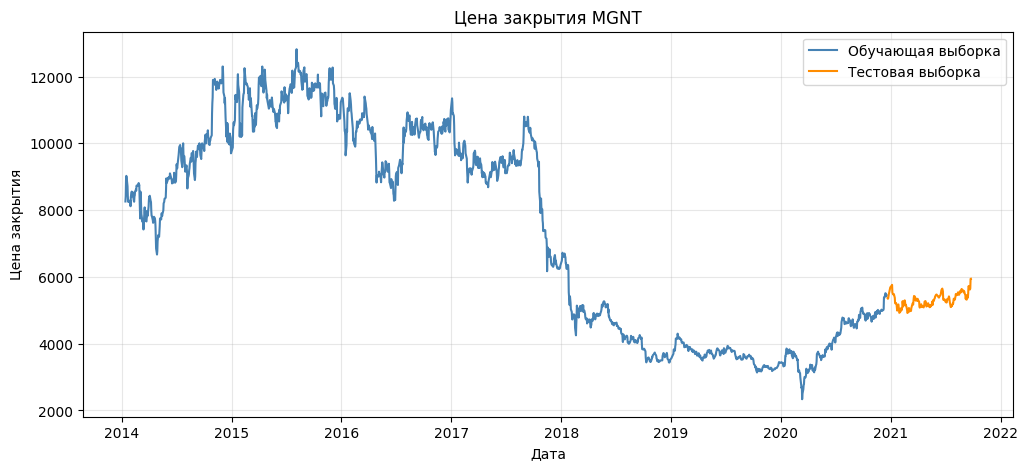

Обучающая выборка: 1748
Тестовая выборка: 195


In [14]:
train_size = int(len(close) * 0.9)
train = close.iloc[:train_size]
test = close.iloc[train_size:]

train_model = pd.Series(train.to_numpy(), index=pd.RangeIndex(len(train)))
test_model = pd.Series(test.to_numpy(), index=pd.RangeIndex(len(train), len(close)))

plt.figure(figsize=(12, 5))
plt.plot(train, label="Обучающая выборка", color="steelblue")
plt.plot(test, label="Тестовая выборка", color="darkorange")
plt.title("Цена закрытия MGNT")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Обучающая выборка: {len(train)}")
print(f"Тестовая выборка: {len(test)}")


In [15]:
def fit_arima_grid(train, p_values=(0, 1, 2), d_values=(1,), q_values=(0, 1, 2)):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    model = SARIMAX(
                        train,
                        order=order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)
                    results.append((model.aic, order, model))
                    print(f"ARIMA{order}: AIC = {model.aic:.2f}")
                except Exception as error:
                    print(f"ARIMA{order}: ошибка - {error}")

    if not results:
        raise RuntimeError("Не удалось построить ни одну ARIMA-модель")

    return min(results, key=lambda item: item[0])


best_aic, best_order, best_model = fit_arima_grid(train_model)
print()
print(f"Лучшая модель: ARIMA{best_order}, AIC = {best_aic:.2f}")


ARIMA(0, 1, 0): AIC = 22714.07
ARIMA(0, 1, 1): AIC = 22693.70
ARIMA(0, 1, 2): AIC = 22681.53
ARIMA(1, 1, 0): AIC = 22714.81
ARIMA(1, 1, 1): AIC = 22698.61
ARIMA(1, 1, 2): AIC = 22682.78
ARIMA(2, 1, 0): AIC = 22694.19
ARIMA(2, 1, 1): AIC = 22695.09
ARIMA(2, 1, 2): AIC = 22680.96

Лучшая модель: ARIMA(2, 1, 2), AIC = 22680.96


In [16]:
def rolling_arima_forecast(model, test_values, forecast_index):
    result = model
    predictions = []

    for actual in test_values:
        prediction = result.get_forecast(steps=1).predicted_mean.iloc[0]
        predictions.append(prediction)

        next_index = pd.RangeIndex(result.nobs, result.nobs + 1)
        new_value = pd.Series([actual], index=next_index)
        result = result.append(new_value, refit=False)

    return pd.Series(predictions, index=forecast_index)


forecast = rolling_arima_forecast(best_model, test.to_numpy(), test.index)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")


MAE: 51.4469
RMSE: 69.3495
MAPE: 0.97%


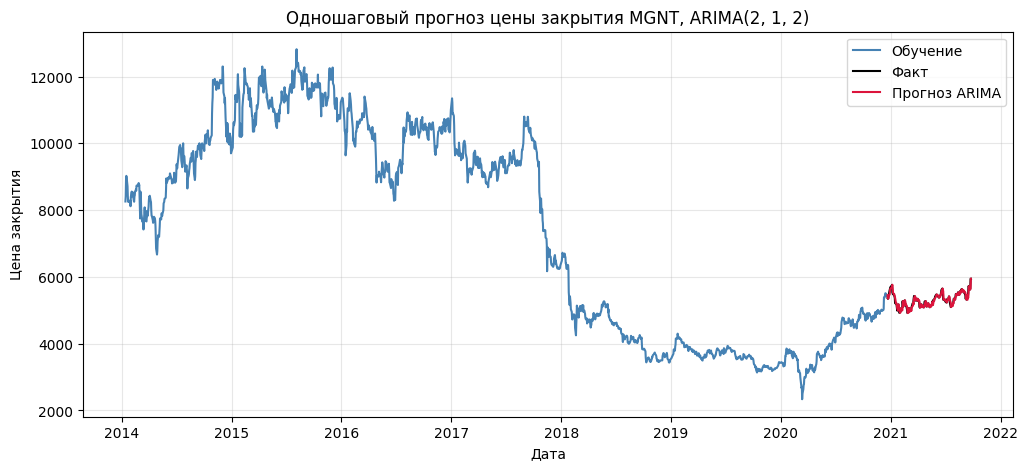

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(train, label="Обучение", color="steelblue")
plt.plot(test, label="Факт", color="black")
plt.plot(forecast, label="Прогноз ARIMA", color="crimson")
plt.title(f"Одношаговый прогноз цены закрытия MGNT, ARIMA{best_order}")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [18]:
def rolling_arimax_forecast(model, test_values, exog_values, forecast_index):
    result = model
    predictions = []

    for actual, (_, exog_row) in zip(test_values, exog_values.iterrows()):
        next_index = pd.RangeIndex(result.nobs, result.nobs + 1)
        exog_next = pd.DataFrame([exog_row.to_numpy()], columns=exog_values.columns, index=next_index)
        prediction = result.get_forecast(steps=1, exog=exog_next).predicted_mean.iloc[0]
        predictions.append(prediction)

        new_value = pd.Series([actual], index=next_index)
        result = result.append(new_value, exog=exog_next, refit=False)

    return pd.Series(predictions, index=forecast_index)


exog_cols = [col for col in [open_col, high_col, low_col, volume_col] if col is not None]

if exog_cols:
    exog = prices.loc[close.index, exog_cols].apply(pd.to_numeric, errors="coerce")
    exog = exog.ffill().bfill()

    exog_train = exog.iloc[:train_size].copy()
    exog_test = exog.iloc[train_size:].copy()
    exog_train.index = train_model.index

    model_exog = SARIMAX(
        train_model,
        exog=exog_train,
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    forecast_exog = rolling_arimax_forecast(model_exog, test.to_numpy(), exog_test, test.index)

    mae_exog = mean_absolute_error(test, forecast_exog)
    rmse_exog = np.sqrt(mean_squared_error(test, forecast_exog))
    mape_exog = np.mean(np.abs((test - forecast_exog) / test)) * 100

    print(f"Признаки для уточнения: {exog_cols}")
    print(f"MAE: {mae_exog:.4f}")
    print(f"RMSE: {rmse_exog:.4f}")
    print(f"MAPE: {mape_exog:.2f}%")
else:
    print("В файле не найдены столбцы Open, High, Low или Volume для уточнения модели")


Признаки для уточнения: ['<OPEN>', '<HIGH>', '<LOW>', '<VOL>']
MAE: 21.8339
RMSE: 27.1705
MAPE: 0.41%


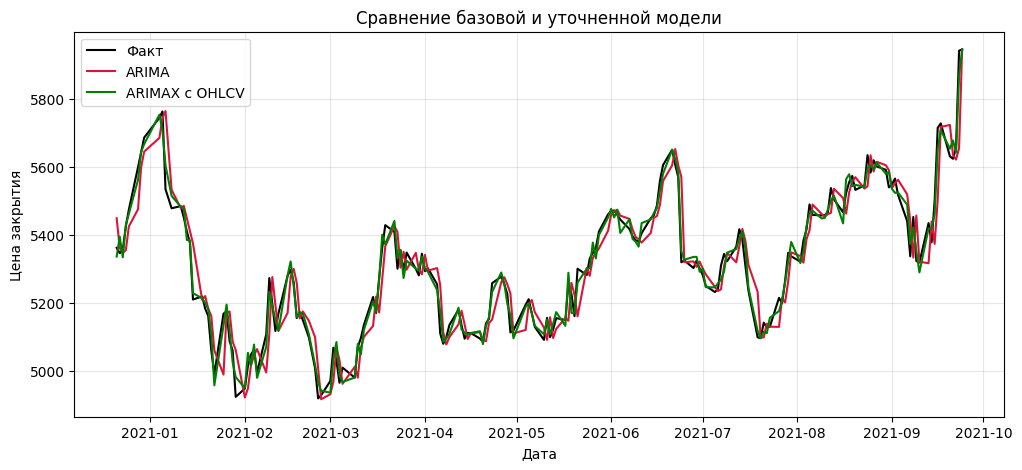

In [19]:
if exog_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(test, label="Факт", color="black")
    plt.plot(forecast, label="ARIMA", color="crimson")
    plt.plot(forecast_exog, label="ARIMAX с OHLCV", color="green")
    plt.title("Сравнение базовой и уточненной модели")
    plt.xlabel("Дата")
    plt.ylabel("Цена закрытия")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Выводы

Модель ARIMA построена по первым 90% значений цены закрытия. Порядок модели выбирается по минимальному AIC на небольшой сетке параметров.

Качество прогноза оценивается на последних 10% ряда с помощью MAE, RMSE и MAPE. Используется одношаговый rolling-прогноз: модель прогнозирует следующий день, затем в историю добавляется фактическое значение тестовой выборки. Такой способ лучше показывает качество краткосрочного прогноза временного ряда, чем прямой прогноз сразу на весь тестовый интервал.

Уточнение модели можно сделать через ARIMAX: добавить внешние признаки Open, High, Low и Volume. Эти признаки несут дополнительную информацию о внутридневном диапазоне цены и активности торгов, поэтому при наличии устойчивой связи они могут уменьшить ошибку прогноза по сравнению с моделью только по Close.
